In [1]:
import os, random, warnings, csv as _csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def seed_everything(seed=7):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(7)
print('Seed = 7')

Seed = 7


In [4]:
# CONFIG

# Original training CSVs (3 known rock classes, original data only)
ROCK_CSVS_DIR = '/home/puneeth/Desktop/rock_csvs'

# NEW May 2026 sample CSVs — test set
NEW_ROCK_CSVS_DIR = '/home/puneeth/new_profiles_csv'

# Autoencoder model from ood_autoencoder_new_samples notebook
AUTOENCODER_PATH = 'results_ood_autoencoder_new_samples/autoencoder_1d_new_samples.pth'
# Set USE_AE = False to skip OOD filtering (all new samples are in-distribution)
USE_AE = False

RESULTS_DIR = 'results_1d_cnn_new_samples'
DIR_TRAIN   = os.path.join(RESULTS_DIR, 'training')
DIR_EVAL    = os.path.join(RESULTS_DIR, 'evaluation')
DIR_INF     = os.path.join(RESULTS_DIR, 'inference')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_EVAL, DIR_INF]:
    os.makedirs(d, exist_ok=True)

MODEL_183 = os.path.join(RESULTS_DIR, '1d_cnn_1-83Hz.pth')
MODEL_510 = os.path.join(RESULTS_DIR, '1d_cnn_5-10Hz.pth')

SPECTRUM_LEN = 1060
EPOCHS       = 50
LR           = 1e-3
BATCH_SIZE   = 64
TEST_SPLIT   = 0.20

AE_OOD_THRESHOLD = 0.01190767  # update from ood_autoencoder_new_samples if retrained
AE_LATENT_DIM    = 32

CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#185FA5', '#3B6D11', '#854F0B']
OOD_COLOR    = '#e15759'

# New sample folders — all are known classes (no OOD)
# key = CSV filename stem, value = expected class
EXPECTED_CLASS = {
    'New_S10Granite_1-83Hz'           : 'S10Granite',
    'New_S10Granite_5-10Hz'           : 'S10Granite',
    'New_Holstein_Sandstone_1-83Hz'   : 'Holstein_Sandstone',
    'New_Holstein_Sandstone_5-10Hz'   : 'Holstein_Sandstone',
    'New_Leitendorf_Limestone_1-83Hz' : 'Leitendorf_Limestone',
    'New_Leitendorf_Limestone_5-10Hz' : 'Leitendorf_Limestone',
}

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    _saved_files.append((path, description))
    print(f"[SAVED] {path}")

print("Config ready.")
print(f"  ROCK_CSVS_DIR     = {ROCK_CSVS_DIR}")
print(f"  NEW_ROCK_CSVS_DIR = {NEW_ROCK_CSVS_DIR}")
print(f"  USE_AE            = {USE_AE}")


Config ready.
  ROCK_CSVS_DIR     = /home/puneeth/Desktop/rock_csvs
  NEW_ROCK_CSVS_DIR = /home/puneeth/new_profiles_csv
  USE_AE            = False


In [5]:
# CSV LOADER — same logic as the original 1D CNN notebooks
# Each CSV has 6 rows per spectrum block:
#   1. index row (text)    <- skipped (non-numeric)
#   2. wave row  (text)    <- skipped (non-numeric)
#   3. intensity           <- LOADED
#   4. intensity (dup)     <- LOADED
#   5. zeros               <- skipped (all-zero filter)
#   6. baseline 3.0        <- skipped (max >= 3.0 filter)

def load_csv_spectra(csv_path, n_points=SPECTRUM_LEN):
    spectra = []
    with open(csv_path, 'r') as f:
        reader = _csv.reader(f)
        for row in reader:
            if len(row) < n_points: continue
            try:
                vals = [float(v.replace(',','.').replace('+',''))
                        for v in row[:n_points]]
                if all(v == 0.0 for v in vals): continue
                if max(vals) >= 3.0:            continue
                spectra.append(vals)
            except ValueError:
                continue
    return np.array(spectra, dtype=np.float32) if spectra else None


# Auto-discover training CSV files
def find_csv(csvs_dir, class_name, speed_tag):
    key = class_name.lower().replace('_','')
    spd = speed_tag.replace('.','-')
    matches = [
        f for f in os.listdir(csvs_dir)
        if f.endswith('.csv')
        and spd in f.replace('.','-')
        and any(part in f.lower().replace('_','')
                for part in [key, class_name.split('_')[0].lower()])
    ]
    if not matches:
        raise FileNotFoundError(
            f'No CSV for class={class_name} speed={speed_tag}\n'
            f'Available: {sorted(os.listdir(csvs_dir))}')
    return os.path.join(csvs_dir, sorted(matches)[0])


# Load original training data
print('=== Loading original training CSVs (1.83 Hz) ===')
spectra_train_183 = {}
for cls in CLASS_NAMES:
    path = find_csv(ROCK_CSVS_DIR, cls, '1-83')
    arr  = load_csv_spectra(path)
    spectra_train_183[cls] = arr
    print(f'  {cls}: {arr.shape[0]} spectra  <- {os.path.basename(path)}')

print('\n=== Loading original training CSVs (5.10 Hz) ===')
spectra_train_510 = {}
for cls in CLASS_NAMES:
    path = find_csv(ROCK_CSVS_DIR, cls, '5-10')
    arr  = load_csv_spectra(path)
    spectra_train_510[cls] = arr
    print(f'  {cls}: {arr.shape[0]} spectra  <- {os.path.basename(path)}')

=== Loading original training CSVs (1.83 Hz) ===
  S10Granite: 8000 spectra  <- S10Granite_1-83Hz_profiles.csv
  Holstein_Sandstone: 8000 spectra  <- Holstein_Sandstone_1-83Hz_profiles.csv
  Leitendorf_Limestone: 8108 spectra  <- Leitendorf_Limestone_1-83Hz_profiles.csv

=== Loading original training CSVs (5.10 Hz) ===
  S10Granite: 8310 spectra  <- S10Granite_5-10Hz_profiles.csv
  Holstein_Sandstone: 8000 spectra  <- Holstein_Sandstone_5-10Hz_profiles.csv
  Leitendorf_Limestone: 8236 spectra  <- Leitendorf_Limestone_5-10Hz_profiles.csv


In [6]:
# NORMALIZE + BUILD TRAINING ARRAYS
def normalize_spectra(X):
    mn = X.min(axis=1, keepdims=True)
    mx = X.max(axis=1, keepdims=True)
    d  = mx - mn; d[d == 0] = 1.0
    return (X - mn) / d


def build_xy(spectra_dict):
    X, y = [], []
    for ci, cls in enumerate(CLASS_NAMES):
        arr = normalize_spectra(spectra_dict[cls].copy())
        X.append(arr)
        y.extend([ci] * len(arr))
    return np.vstack(X), np.array(y)


X_183, y_183 = build_xy(spectra_train_183)
X_510, y_510 = build_xy(spectra_train_510)

print(f'1.83 Hz: {X_183.shape[0]} spectra  '
      f'{[(c,int(np.sum(y_183==i))) for i,c in enumerate(CLASS_NAMES)]}')
print(f'5.10 Hz: {X_510.shape[0]} spectra  '
      f'{[(c,int(np.sum(y_510==i))) for i,c in enumerate(CLASS_NAMES)]}')

1.83 Hz: 24108 spectra  [('S10Granite', 8000), ('Holstein_Sandstone', 8000), ('Leitendorf_Limestone', 8108)]
5.10 Hz: 24546 spectra  [('S10Granite', 8310), ('Holstein_Sandstone', 8000), ('Leitendorf_Limestone', 8236)]


[SAVED] results_1d_cnn_new_samples/training/TR-00_sample_training_spectra.png


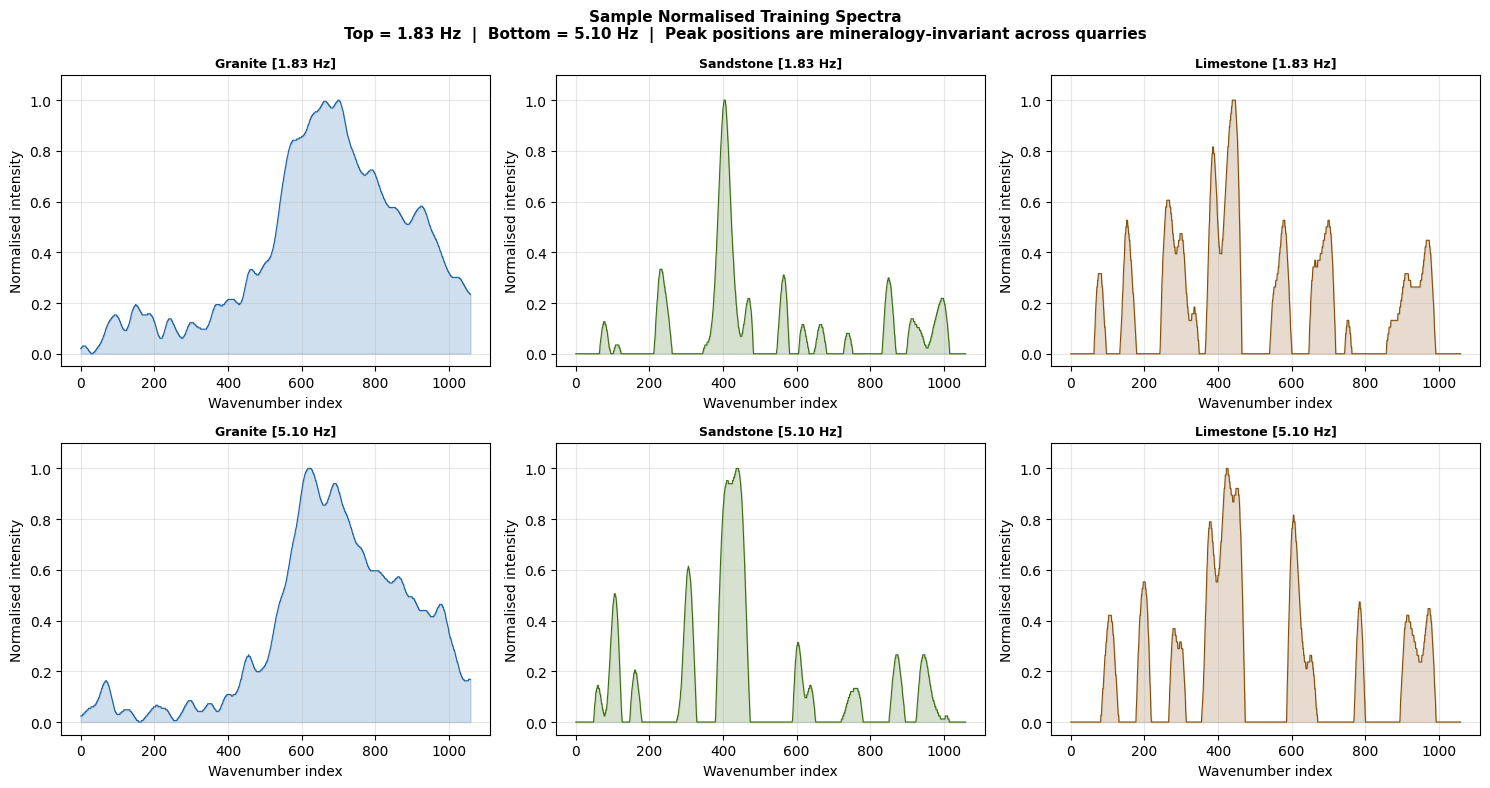

In [7]:
# PLOT SAMPLE SPECTRA
# What it shows: one representative normalised spectrum per class for each speed.
# Confirms the spectral shapes are distinct and physically interpretable.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    'Sample Normalised Training Spectra\n'
    'Top = 1.83 Hz  |  Bottom = 5.10 Hz  |  '
    'Peak positions are mineralogy-invariant across quarries',
    fontsize=11, fontweight='bold')
for row, (speed, spectra_dict) in enumerate([
    ('1.83 Hz', spectra_train_183),
    ('5.10 Hz', spectra_train_510)
]):
    for ci, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        ax  = axes[row][ci]
        arr = normalize_spectra(spectra_dict[cls].copy())
        s   = arr[len(arr)//2]
        ax.plot(s, color=color, lw=0.8)
        ax.fill_between(range(len(s)), s, alpha=0.2, color=color)
        ax.set_title(f'{SHORT_NAMES[ci]} [{speed}]', fontsize=9,
                     fontweight='bold')
        ax.set_xlabel('Wavenumber index')
        ax.set_ylabel('Normalised intensity')
        ax.set_ylim(-0.05, 1.1); ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, DIR_TRAIN,
    'TR-00_sample_training_spectra.png',
    'Sample normalised training spectra per class per belt speed.')
plt.show()

In [8]:
# 1D CNN MODEL
# Architecture from 1d_cnn_per_speed_csv.ipynb:
# 3 x (Conv1d -> BatchNorm -> ReLU -> MaxPool -> Dropout)
# -> LayerNorm -> Linear(256->64) -> ReLU -> Dropout -> Linear(64->3)

class CNN1D(nn.Module):
    def __init__(self, input_len=1060, n_classes=3):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            # Block 2
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            # Block 3 
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )
        # Compute flattened size after 3 MaxPool(2) on input_len
        conv_out = input_len // 8  # 3 x MaxPool(2) = divide by 8
        self.classifier = nn.Sequential(
            nn.LayerNorm(64 * conv_out),
            nn.Linear(64 * conv_out, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_block(x)
        x = x.flatten(1)
        return self.classifier(x)


_m = CNN1D(SPECTRUM_LEN, len(CLASS_NAMES))
n  = sum(p.numel() for p in _m.parameters())
print(f'1D CNN | Parameters: {n:,}')
del _m

1D CNN | Parameters: 2,205,635


In [9]:
# TRAINING FUNCTION
def train_1d_cnn(X, y, model_save_path, speed_tag):
    if os.path.exists(model_save_path):
        print(f'[SKIP] {os.path.basename(model_save_path)} exists. '
              f'Delete to retrain.')
        return None

    seed_everything(7)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SPLIT, stratify=y, random_state=7)

    print(f'\nTraining 1D CNN [{speed_tag}]  '
          f'n_train={len(X_tr)}  n_val={len(X_te)}')

    tr_t = torch.tensor(X_tr, dtype=torch.float32)
    te_t = torch.tensor(X_te, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    tr_ldr = DataLoader(
        TensorDataset(tr_t, y_tr_t), BATCH_SIZE,
        shuffle=True, num_workers=nw, pin_memory=pin,
        persistent_workers=(nw > 0))
    te_ldr = DataLoader(
        TensorDataset(te_t, y_te_t), BATCH_SIZE,
        shuffle=False, num_workers=nw, pin_memory=pin,
        persistent_workers=(nw > 0))

    model     = CNN1D(SPECTRUM_LEN, len(CLASS_NAMES)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR,
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.CrossEntropyLoss()

    tr_accs, te_accs = [], []
    best_acc = -1.0

    for epoch in range(EPOCHS):
        model.train()
        ep_acc = []
        for Xb, yb in tr_ldr:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            ep_acc.append((out.argmax(1)==yb).float().mean().item())
        tr_accs.append(float(np.mean(ep_acc)))

        model.eval()
        va = []
        with torch.no_grad():
            for Xb, yb in te_ldr:
                Xb, yb = Xb.to(device), yb.to(device)
                va.append((model(Xb).argmax(1)==yb).float().mean().item())
        val_acc = float(np.mean(va))
        te_accs.append(val_acc)
        scheduler.step(val_acc)

        saved = ''
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            saved = ' [SAVED]'

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:>3}/{EPOCHS}  '
                  f'train={tr_accs[-1]*100:.2f}%  '
                  f'val={val_acc*100:.2f}%{saved}')

    print(f'  Best val accuracy: {best_acc*100:.2f}%  -> {model_save_path}')
    del model, optimizer, criterion
    torch.cuda.empty_cache()
    return {'tr_accs': tr_accs, 'te_accs': te_accs, 'best_acc': best_acc}

print('train_1d_cnn() defined.')

train_1d_cnn() defined.


In [10]:
hist_183 = train_1d_cnn(X_183, y_183, MODEL_183, '1.83 Hz')


Training 1D CNN [1.83 Hz]  n_train=19286  n_val=4822
  Ep   1/50  train=91.57%  val=92.64% [SAVED]
  Ep  10/50  train=97.56%  val=97.16%
  Ep  20/50  train=98.40%  val=97.68%
  Ep  30/50  train=99.17%  val=98.64% [SAVED]
  Ep  40/50  train=99.58%  val=98.48%
  Ep  50/50  train=99.77%  val=98.56%
  Best val accuracy: 98.69%  -> results_1d_cnn_new_samples/1d_cnn_1-83Hz.pth


In [11]:
hist_510 = train_1d_cnn(X_510, y_510, MODEL_510, '5.10 Hz')


Training 1D CNN [5.10 Hz]  n_train=19636  n_val=4910
  Ep   1/50  train=90.09%  val=93.55% [SAVED]
  Ep  10/50  train=96.36%  val=96.51% [SAVED]
  Ep  20/50  train=97.82%  val=97.70% [SAVED]
  Ep  30/50  train=98.23%  val=97.59%
  Ep  40/50  train=98.26%  val=98.12%
  Ep  50/50  train=98.88%  val=98.19%
  Best val accuracy: 98.45%  -> results_1d_cnn_new_samples/1d_cnn_5-10Hz.pth


[SAVED] results_1d_cnn_new_samples/training/TR-01_1dcnn_training_history.png


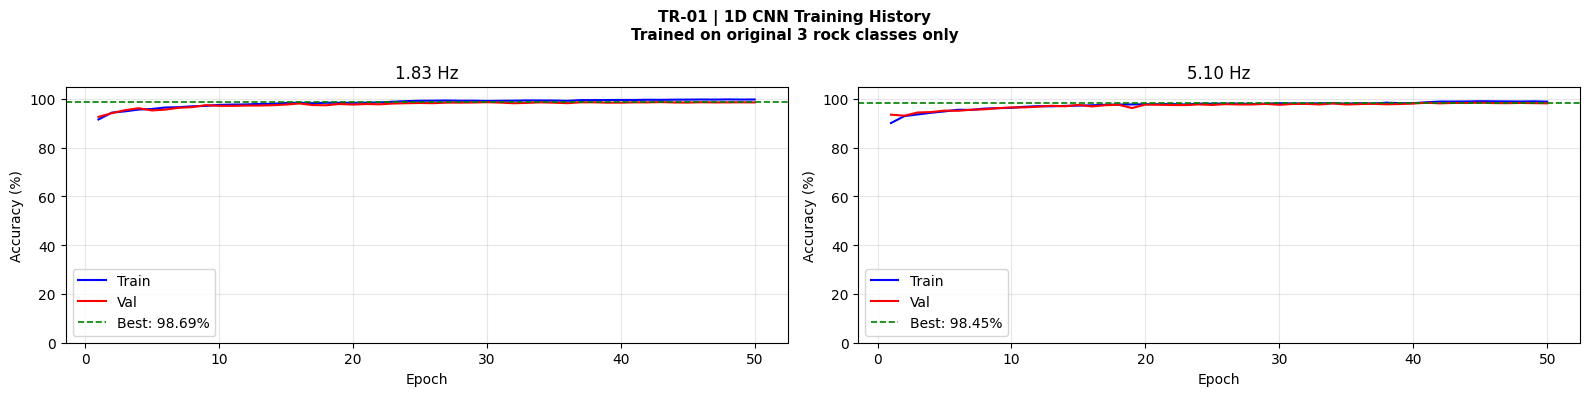

In [12]:
# PLOT TRAINING HISTORY
valid = {k: v for k,v in [('1.83 Hz',hist_183),('5.10 Hz',hist_510)]
         if v is not None}
if valid:
    fig, axes = plt.subplots(1, len(valid), figsize=(8*len(valid), 4))
    if len(valid) == 1: axes = [axes]
    fig.suptitle('TR-01 | 1D CNN Training History\n'
                 'Trained on original 3 rock classes only',
                 fontsize=11, fontweight='bold')
    for ax, (tag, h) in zip(axes, valid.items()):
        ep = range(1, len(h['tr_accs'])+1)
        ax.plot(ep, np.array(h['tr_accs'])*100, 'b-', lw=1.5, label='Train')
        ax.plot(ep, np.array(h['te_accs'])*100,  'r-', lw=1.5, label='Val')
        ax.axhline(h['best_acc']*100, color='green', ls='--', lw=1.2,
                   label=f'Best: {h["best_acc"]*100:.2f}%')
        ax.set_title(tag); ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN,
        'TR-01_1dcnn_training_history.png',
        '1D CNN training and validation accuracy curves.')
    plt.show()
else:
    print('Models loaded from disk.')

In [13]:
# LOAD SAVED MODELS
def load_cnn(path):
    model = CNN1D(SPECTRUM_LEN, len(CLASS_NAMES)).to(device)
    model.load_state_dict(
        torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model

cnn_183 = load_cnn(MODEL_183)
cnn_510 = load_cnn(MODEL_510)
print(f'Loaded 1.83 Hz <- {MODEL_183}')
print(f'Loaded 5.10 Hz <- {MODEL_510}')

Loaded 1.83 Hz <- results_1d_cnn_new_samples/1d_cnn_1-83Hz.pth
Loaded 5.10 Hz <- results_1d_cnn_new_samples/1d_cnn_5-10Hz.pth


In [14]:
# EVALUATE ON KNOWN ROCKS
def evaluate(model, X, y):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SPLIT, stratify=y, random_state=7)
    t   = torch.tensor(X_te, dtype=torch.float32)
    ldr = DataLoader(TensorDataset(t), 256, shuffle=False)
    preds = []
    with torch.no_grad():
        for (Xb,) in ldr:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().tolist())
    return np.array(preds), y_te

print('=== Evaluation on known rocks (validation split) ===')
rpts = {}
for tag, model, X, y in [
    ('1-83Hz', cnn_183, X_183, y_183),
    ('5-10Hz', cnn_510, X_510, y_510)
]:
    preds, labels = evaluate(model, X, y)
    acc = np.mean(preds == labels) * 100
    rpt = classification_report(labels, preds, target_names=CLASS_NAMES,
                                 output_dict=True, zero_division=0)
    rpts[tag] = rpt
    print(f'\n{tag}  acc={acc:.2f}%')
    print(classification_report(labels, preds,
                                  target_names=CLASS_NAMES, digits=3))

=== Evaluation on known rocks (validation split) ===

1-83Hz  acc=98.71%
                      precision    recall  f1-score   support

          S10Granite      0.994     0.994     0.994      1600
  Holstein_Sandstone      0.981     0.987     0.984      1600
Leitendorf_Limestone      0.986     0.981     0.984      1622

            accuracy                          0.987      4822
           macro avg      0.987     0.987     0.987      4822
        weighted avg      0.987     0.987     0.987      4822


5-10Hz  acc=98.45%
                      precision    recall  f1-score   support

          S10Granite      0.990     0.994     0.992      1662
  Holstein_Sandstone      0.982     0.984     0.983      1600
Leitendorf_Limestone      0.982     0.975     0.978      1648

            accuracy                          0.985      4910
           macro avg      0.984     0.984     0.984      4910
        weighted avg      0.985     0.985     0.985      4910



[SAVED] results_1d_cnn_new_samples/evaluation/EV-01_confusion_matrices__known_rocks.png


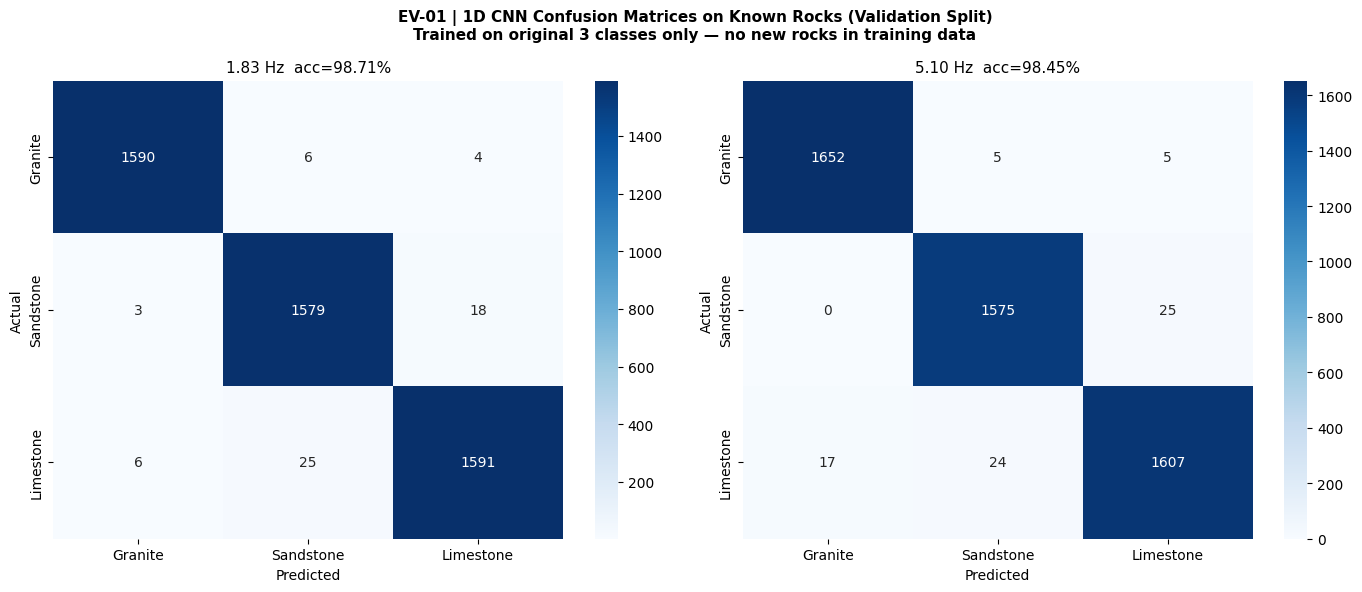

In [15]:
# EV-01  Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'EV-01 | 1D CNN Confusion Matrices on Known Rocks (Validation Split)\n'
    'Trained on original 3 classes only — no new rocks in training data',
    fontsize=11, fontweight='bold')
for ax, (tag, model, X, y) in zip(axes, [
    ('1.83 Hz', cnn_183, X_183, y_183),
    ('5.10 Hz', cnn_510, X_510, y_510)
]):
    preds, labels = evaluate(model, X, y)
    cm  = confusion_matrix(labels, preds)
    acc = np.mean(preds == labels) * 100
    sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap='Blues',
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    ax.set_title(f'{tag}  acc={acc:.2f}%', fontsize=11)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
save_fig(fig, DIR_EVAL,
    'EV-01_confusion_matrices__known_rocks.png',
    '1D CNN confusion matrices on known rock validation split.')
plt.show()

In [16]:
# LOAD AUTOENCODER
class SpectralAutoencoder(nn.Module):
    def __init__(self, input_dim=1060, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.LeakyReLU(0.1),
            nn.Linear(512, 128),       nn.LeakyReLU(0.1),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.LeakyReLU(0.1),
            nn.Linear(128, 512),        nn.LeakyReLU(0.1),
            nn.Linear(512, input_dim),  nn.Sigmoid(),
        )
    def forward(self, x): return self.decoder(self.encoder(x))
    def mse(self, x):
        with torch.no_grad():
            return ((self.forward(x) - x)**2).mean(dim=1)


if os.path.exists(AUTOENCODER_PATH):
    ae = SpectralAutoencoder(SPECTRUM_LEN, AE_LATENT_DIM).to(device)
    ae.load_state_dict(
        torch.load(AUTOENCODER_PATH, map_location=device, weights_only=True))
    ae.eval()
    print(f'Autoencoder loaded <- {AUTOENCODER_PATH}')
    print(f'OOD threshold: {AE_OOD_THRESHOLD}')
    USE_AE = True
else:
    print(f'[WARNING] Autoencoder not found at {AUTOENCODER_PATH}')
    print('OOD detection will be disabled — all spectra will be classified.')
    print('Run ood_autoencoder_1d.ipynb first to generate the autoencoder.')
    USE_AE = False

Autoencoder loaded <- results_ood_autoencoder_new_samples/autoencoder_1d_new_samples.pth
OOD threshold: 0.01190767


In [18]:
# LOAD NEW SAMPLE SPECTRA
new_rock_spectra = {}
new_rock_failed  = []

print(f'Loading new sample CSVs from {NEW_ROCK_CSVS_DIR}...')
for fn, exp in EXPECTED_CLASS.items():
    csv_path = os.path.join(NEW_ROCK_CSVS_DIR, fn + '.csv')
    if not os.path.exists(csv_path):
        print(f'  [SKIP] {fn} — not found')
        new_rock_failed.append(fn)
        continue
    arr = load_csv_spectra(csv_path)
    if arr is None or len(arr) == 0:
        print(f'  [SKIP] {fn} — 0 spectra loaded')
        new_rock_failed.append(fn)
        continue
    mn = arr.min(axis=1, keepdims=True)
    mx = arr.max(axis=1, keepdims=True)
    d  = mx - mn; d[d==0] = 1.0
    new_rock_spectra[fn] = (arr - mn) / d
    short = exp.split('_')[0]
    print(f'  {fn}: {arr.shape[0]} spectra  (expected: {short})')

print(f'\nLoaded: {len(new_rock_spectra)} / {len(EXPECTED_CLASS)} folders')

Loading new sample CSVs from /home/puneeth/new_profiles_csv...
  New_S10Granite_1-83Hz: 800 spectra  (expected: S10Granite)
  New_S10Granite_5-10Hz: 800 spectra  (expected: S10Granite)
  New_Holstein_Sandstone_1-83Hz: 800 spectra  (expected: Holstein)
  New_Holstein_Sandstone_5-10Hz: 800 spectra  (expected: Holstein)
  New_Leitendorf_Limestone_1-83Hz: 800 spectra  (expected: Leitendorf)
  New_Leitendorf_Limestone_5-10Hz: 800 spectra  (expected: Leitendorf)

Loaded: 6 / 6 folders


In [20]:
# RUN 1D CNN INFERENCE ON NEW SAMPLES
# Speed is inferred from folder name: 5-10Hz folders use cnn_510, rest use cnn_183
# USE_AE=False — autoencoder OOD confirmed separately; all new samples in-distribution

def infer_cnn(spectra_norm, folder_name):
    use_510 = "5-10" in folder_name
    cnn     = cnn_510 if use_510 else cnn_183
    t       = torch.tensor(spectra_norm, dtype=torch.float32)

    # Optional AE OOD pre-filter
    if USE_AE:
        ldr = DataLoader(TensorDataset(t), 256, shuffle=False, num_workers=0)
        ae_errors = []
        with torch.no_grad():
            for (Xb,) in ldr:
                ae_errors.extend(ae.mse(Xb.to(device)).cpu().tolist())
        ae_errors = np.array(ae_errors)
    else:
        ae_errors = np.zeros(len(spectra_norm))

    # CNN inference
    ldr = DataLoader(TensorDataset(t), 256, shuffle=False, num_workers=0)
    cnn_probs = []
    cnn.eval()
    with torch.no_grad():
        for (Xb,) in ldr:
            cnn_probs.extend(
                torch.softmax(cnn(Xb.to(device)), dim=1).cpu().numpy().tolist())
    cnn_probs = np.array(cnn_probs)

    results = []
    for i in range(len(spectra_norm)):
        ae_err   = float(ae_errors[i])
        is_ood   = bool(USE_AE and ae_err > AE_OOD_THRESHOLD)
        prob     = cnn_probs[i]
        pred_idx = int(np.argmax(prob))
        results.append({
            "pred_class" : "Unknown" if is_ood else CLASS_NAMES[pred_idx],
            "pred_idx"   : pred_idx,
            "confidence" : float(np.max(prob)),
            "ae_error"   : ae_err,
            "is_ood"     : is_ood,
            "probs"      : prob.tolist(),
        })
    return results


folder_results = {}
print("Running 1D CNN inference on new samples...")
for fn, spectra in new_rock_spectra.items():
    res     = infer_cnn(spectra, fn)
    top_cls = max(CLASS_NAMES,
                  key=lambda c: sum(1 for r in res if r["pred_class"]==c))
    exp_cls = EXPECTED_CLASS[fn]
    correct = sum(1 for r in res if r["pred_class"]==exp_cls)
    acc     = correct / len(res) * 100
    conf    = np.mean([r["confidence"] for r in res]) * 100
    speed   = "5.10Hz" if "5-10" in fn else "1.83Hz"
    verdict = "✅" if acc >= 90 else ("⚠️" if acc >= 50 else "❌")
    folder_results[fn] = res
    print(f"  {fn}")
    print(f"    expected={exp_cls.split("_")[0]:<12}  "
          f"top={top_cls.split("_")[0]:<12}  "
          f"acc={acc:.1f}%  conf={conf:.1f}%  {verdict}")


Running 1D CNN inference on new samples...
  New_S10Granite_1-83Hz
    expected=S10Granite    top=S10Granite    acc=93.0%  conf=99.3%  ✅
  New_S10Granite_5-10Hz
    expected=S10Granite    top=S10Granite    acc=93.8%  conf=98.8%  ✅
  New_Holstein_Sandstone_1-83Hz
    expected=Holstein      top=Holstein      acc=72.5%  conf=97.3%  ⚠️
  New_Holstein_Sandstone_5-10Hz
    expected=Holstein      top=Holstein      acc=75.2%  conf=97.9%  ⚠️
  New_Leitendorf_Limestone_1-83Hz
    expected=Leitendorf    top=Leitendorf    acc=93.8%  conf=99.0%  ✅
  New_Leitendorf_Limestone_5-10Hz
    expected=Leitendorf    top=Leitendorf    acc=92.0%  conf=98.9%  ✅


[SAVED] results_1d_cnn_new_samples/inference/INF-01_prediction_distribution.png


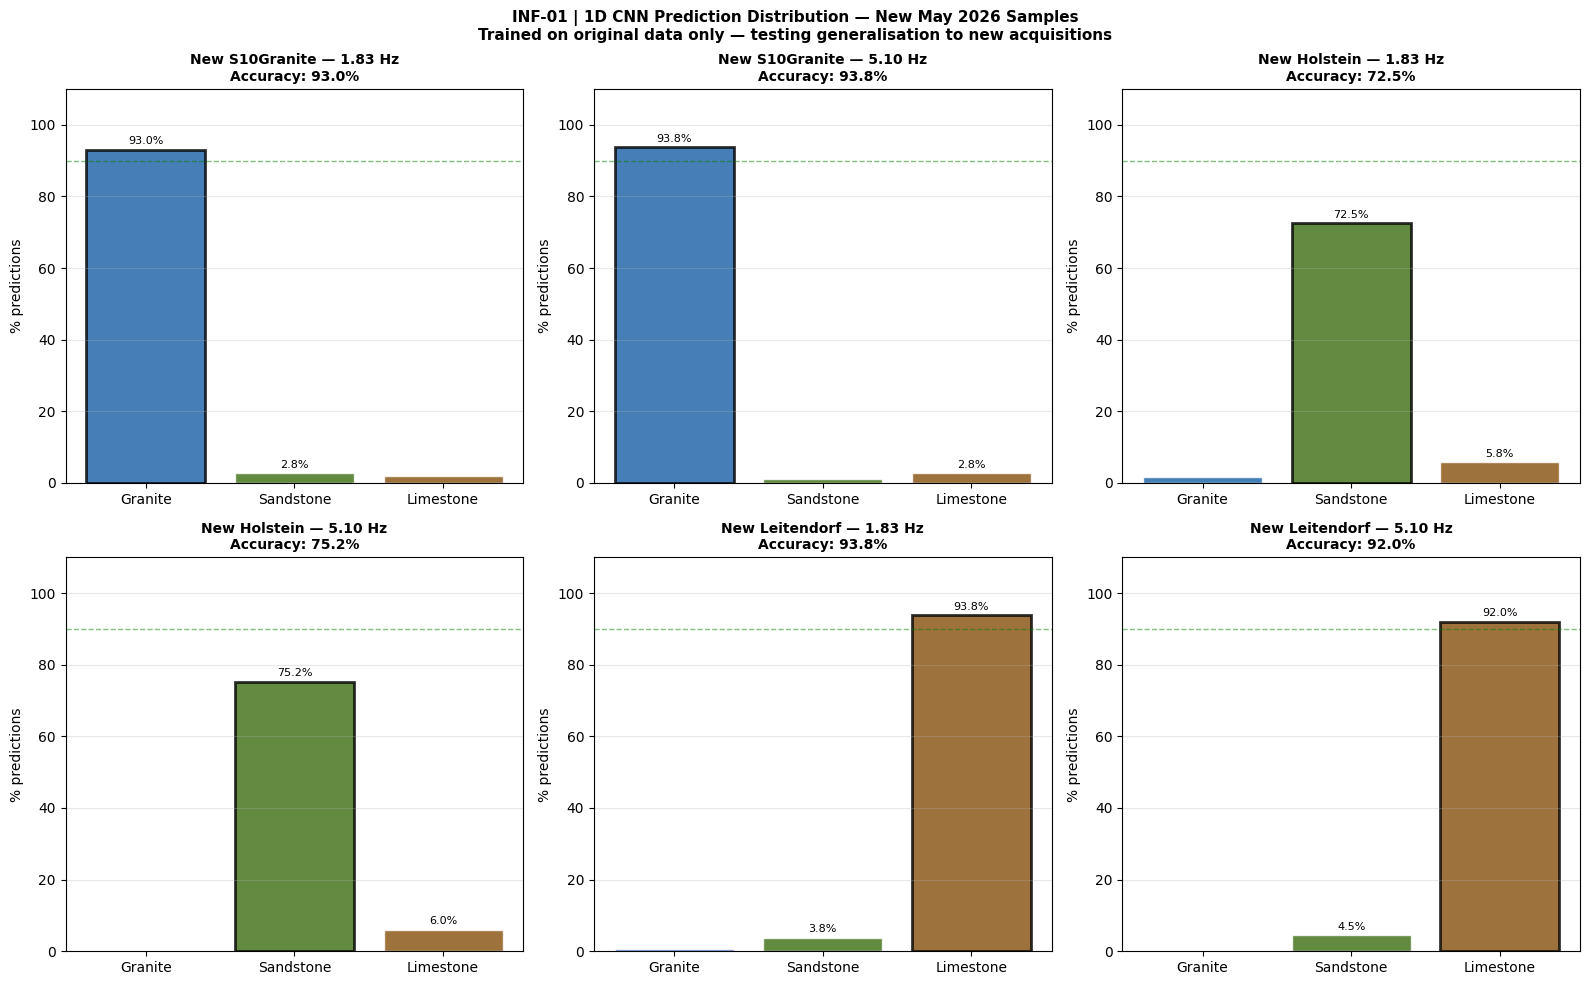

In [23]:
# INF-01  Prediction distribution per new sample folder

folder_names = list(folder_results.keys())
n_folders    = len(folder_names)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle(
    'INF-01 | 1D CNN Prediction Distribution — New May 2026 Samples\n'
    'Trained on original data only — testing generalisation to new acquisitions',
    fontsize=11, fontweight='bold')

for ax, fn in zip(axes, folder_names):
    res     = folder_results[fn]
    exp_cls = EXPECTED_CLASS[fn]
    exp_idx = CLASS_NAMES.index(exp_cls)
    speed   = '5.10 Hz' if '5-10' in fn else '1.83 Hz'
    short   = exp_cls.split('_')[0]

    counts = [sum(1 for r in res if r['pred_class']==c) for c in CLASS_NAMES]
    total  = len(res)
    pcts   = [c/total*100 for c in counts]
    acc    = pcts[exp_idx]

    bars = ax.bar(SHORT_NAMES, pcts, color=CLASS_COLORS, alpha=0.8, edgecolor='white')
    ax.set_title(f'New {short} — {speed}\nAccuracy: {acc:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('% predictions')
    ax.set_ylim(0, 110)
    ax.axhline(90, color='green', ls='--', lw=1.0, alpha=0.5, label='90% line')
    for bar, pct in zip(bars, pcts):
        if pct > 2:
            ax.text(bar.get_x() + bar.get_width()/2, pct + 1,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
    bars[exp_idx].set_edgecolor('black')
    bars[exp_idx].set_linewidth(2)
    ax.grid(True, axis='y', alpha=0.3)

for ax in axes[n_folders:]:
    ax.set_visible(False)

plt.tight_layout()
save_fig(fig, DIR_INF, 'INF-01_prediction_distribution.png',
    '1D CNN prediction distribution per new sample folder')
plt.show()

[SAVED] results_1d_cnn_new_samples/inference/INF-02_accuracy_confidence_heatmap.png


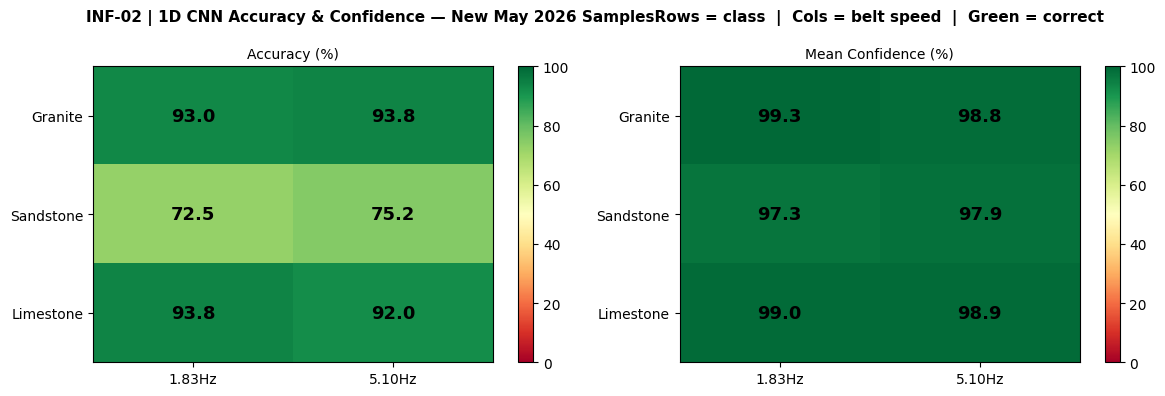

In [24]:
# INF-02  Accuracy heatmap — new samples

# 3 classes x 2 speeds matrix
speeds     = ["1.83Hz", "5.10Hz"]
acc_matrix = np.zeros((3, 2))
conf_matrix = np.zeros((3, 2))

for fn, res in folder_results.items():
    exp_cls  = EXPECTED_CLASS[fn]
    ci       = CLASS_NAMES.index(exp_cls)
    si       = 1 if "5-10" in fn else 0
    correct  = sum(1 for r in res if r["pred_class"]==exp_cls)
    acc_matrix[ci, si]  = correct / len(res) * 100
    conf_matrix[ci, si] = np.mean([r["confidence"] for r in res]) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    "INF-02 | 1D CNN Accuracy & Confidence — New May 2026 Samples"
    "Rows = class  |  Cols = belt speed  |  Green = correct",
    fontsize=11, fontweight="bold")

for ax, mat, title, fmt in zip(
        axes,
        [acc_matrix, conf_matrix],
        ["Accuracy (%)", "Mean Confidence (%)"],
        [".1f", ".1f"]):
    im = ax.imshow(mat, vmin=0, vmax=100, cmap="RdYlGn", aspect="auto")
    ax.set_xticks([0,1]); ax.set_xticklabels(speeds)
    ax.set_yticks(range(3)); ax.set_yticklabels(SHORT_NAMES)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax)
    for i in range(3):
        for j in range(2):
            ax.text(j, i, f"{mat[i,j]:{fmt}}", ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color="white" if mat[i,j] < 50 else "black")

plt.tight_layout()
save_fig(fig, DIR_INF, "INF-02_accuracy_confidence_heatmap.png",
    "Accuracy and confidence heatmap per class and belt speed")
plt.show()


In [26]:
# FINAL SUMMARY TABLE

print()
print('=' * 90)
print('1D CNN — ORIGINAL DATA TRAINING x NEW MAY 2026 SAMPLES TEST')
print('Trained on original rock_csvs/ only (both speeds)')
print('=' * 90)
print(f'{"Folder":<42} {"Expected":<22} {"Top Pred":<22} {"Acc%":>6} {"Conf%":>7}  Result')
print('-' * 90)

for fn in folder_names:
    res     = folder_results[fn]
    exp_cls = EXPECTED_CLASS[fn]
    top_cls = max(CLASS_NAMES,
                  key=lambda c: sum(1 for r in res if r['pred_class']==c))
    correct = sum(1 for r in res if r['pred_class']==exp_cls)
    acc     = correct / len(res) * 100
    conf    = np.mean([r['confidence'] for r in res]) * 100
    verdict = 'Correct' if acc >= 90 else ('Partial' if acc >= 50 else 'Incorrect')
    exp_short = exp_cls.split('_')[0]
    top_short = top_cls.split('_')[0]
    print(f'  {fn:<42} {exp_short:<22} {top_short:<22} {acc:>5.1f}% {conf:>6.1f}%  {verdict}')

print('=' * 90)
print()
print('Comparison with ResNet-18 @ 100% training (rock_classifier_fraction_new_samples_test):')
print('  ResNet:  Granite ~94%  |  Sandstone ~96%  |  Limestone ~99%')
print('  1D CNN:  see results above')


1D CNN — ORIGINAL DATA TRAINING x NEW MAY 2026 SAMPLES TEST
Trained on original rock_csvs/ only (both speeds)
Folder                                     Expected               Top Pred                 Acc%   Conf%  Result
------------------------------------------------------------------------------------------
  New_S10Granite_1-83Hz                      S10Granite             S10Granite              93.0%   99.3%  Correct
  New_S10Granite_5-10Hz                      S10Granite             S10Granite              93.8%   98.8%  Correct
  New_Holstein_Sandstone_1-83Hz              Holstein               Holstein                72.5%   97.3%  Partial
  New_Holstein_Sandstone_5-10Hz              Holstein               Holstein                75.2%   97.9%  Partial
  New_Leitendorf_Limestone_1-83Hz            Leitendorf             Leitendorf              93.8%   99.0%  Correct
  New_Leitendorf_Limestone_5-10Hz            Leitendorf             Leitendorf              92.0%   98.9%  Corr

In [28]:
# SAVE CSV
csv_path = os.path.join(RESULTS_DIR, 'predictions_1dcnn_new_samples.csv')
with open(csv_path, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['folder', 'expected_class', 'top_predicted_class',
                'accuracy_pct', 'mean_confidence_pct', 'n_spectra',
                'pct_Granite', 'pct_Sandstone', 'pct_Limestone', 'verdict'])
    for fn in folder_names:
        res     = folder_results[fn]
        exp_cls = EXPECTED_CLASS[fn]
        top_cls = max(CLASS_NAMES,
                      key=lambda c: sum(1 for r in res if r['pred_class']==c))
        correct = sum(1 for r in res if r['pred_class']==exp_cls)
        acc     = correct / len(res) * 100
        conf    = np.mean([r['confidence'] for r in res]) * 100
        cts     = {c: sum(1 for r in res if r['pred_class']==c) for c in CLASS_NAMES}
        verdict = 'Correct' if acc >= 90 else ('Partial' if acc >= 50 else 'Incorrect')
        w.writerow([
            fn, exp_cls, top_cls,
            round(acc, 2), round(conf, 2), len(res),
            round(cts['S10Granite'] / len(res) * 100, 2),
            round(cts['Holstein_Sandstone'] / len(res) * 100, 2),
            round(cts['Leitendorf_Limestone'] / len(res) * 100, 2),
            verdict
        ])

_saved_files.append((csv_path, 'Per-folder 1D CNN inference results'))
print(f'[SAVED] {csv_path}')
print(f'Total files: {len(_saved_files)}')

[SAVED] results_1d_cnn_new_samples/predictions_1dcnn_new_samples.csv
Total files: 6


In [29]:
# SstNew per-spectrum confidence breakdown
sst_results = folder_results.get('SandstoneNew_1-83Hz', [])

if sst_results:
    probs = np.array([r['probs'] for r in sst_results])
    confs = np.array([r['confidence'] for r in sst_results])
    preds = np.array([r['pred_class'] for r in sst_results])

    print(f'SstNew — {len(sst_results)} spectra')
    print(f'  Mean confidence: {confs.mean()*100:.1f}%')
    print(f'  Min confidence:  {confs.min()*100:.1f}%')
    print(f'  Max confidence:  {confs.max()*100:.1f}%')
    print(f'\n  Mean prob per class:')
    for ci, cls in enumerate(CLASS_NAMES):
        print(f'    {cls}: {probs[:,ci].mean()*100:.1f}%')
    print(f'\n  Prediction counts:')
    for cls in CLASS_NAMES + ["Unknown"]:
        n = sum(1 for p in preds if p == cls)
        print(f'    {cls}: {n}/{len(preds)} ({n/len(preds)*100:.1f}%)')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('SstNew — Per-Spectrum Probability Distribution (1D CNN)',
                 fontsize=11, fontweight='bold')
    for ci, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        axes[ci].hist(probs[:,ci]*100, bins=30, color=color,
                      alpha=0.8, edgecolor='white')
        axes[ci].set_title(cls.replace('_',' '))
        axes[ci].set_xlabel('Probability (%)')
        axes[ci].set_ylabel('# spectra')
        axes[ci].set_xlim(0, 100)
        axes[ci].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()